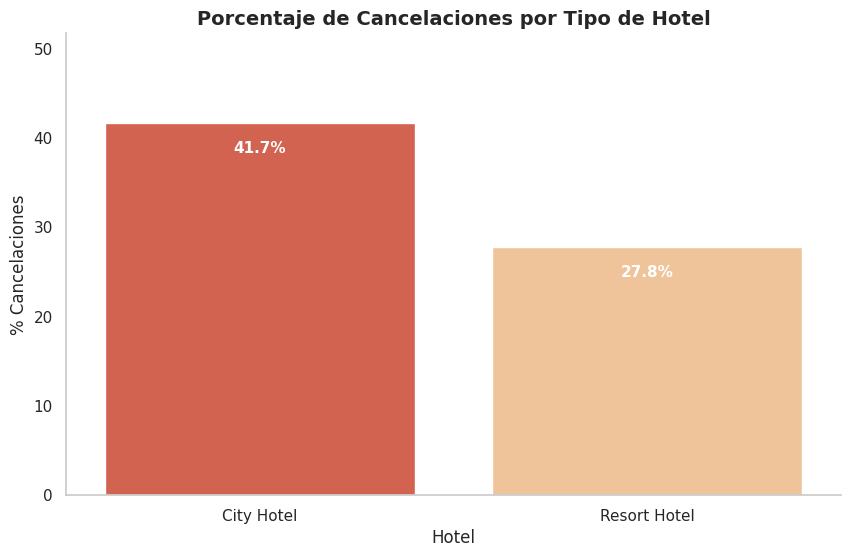

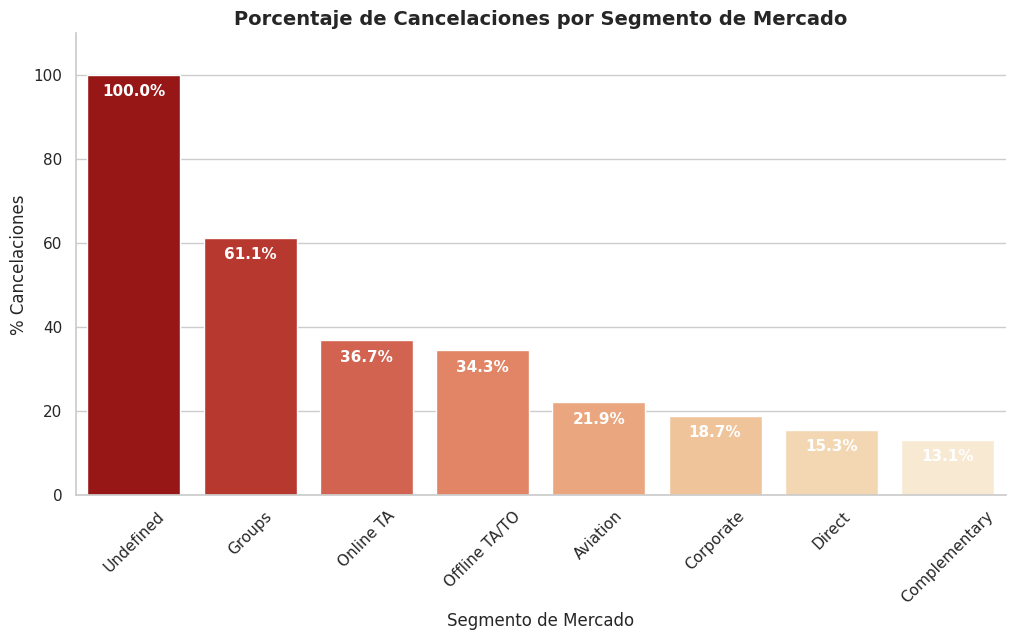

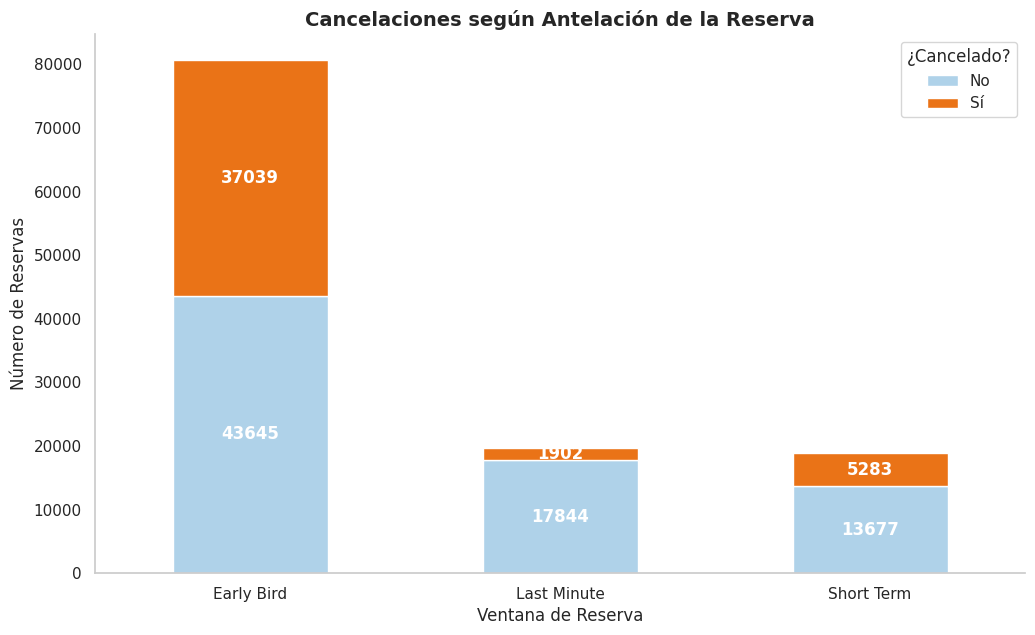

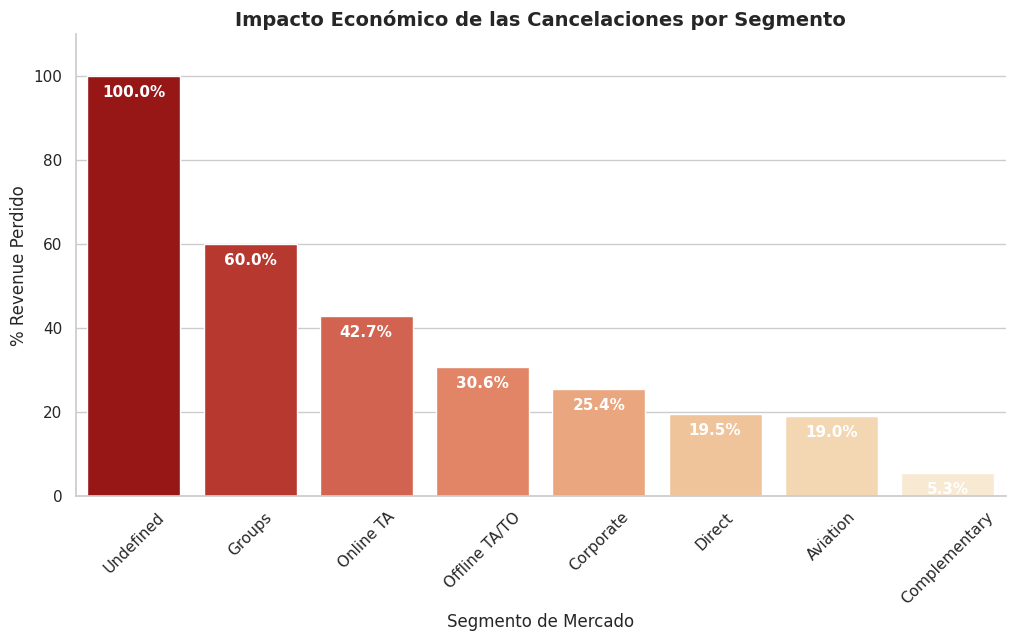

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración general

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
colores_basicos = ["#AFD2E9", "#EA7317"]  # Azul: No cancelado, Naranja: Cancelado

# Cargar CSV limpio y exportado de MySQL
df = pd.read_csv("/content/clean_data.csv", sep=';', quotechar='"')

# Crear columna de revenue perdido
df['revenue_lost'] = df['potential_revenue'] * df['is_canceled']

# 1️. Cancelaciones por tipo de hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].agg(['count','sum']).reset_index()
cancel_hotel.rename(columns={'count':'total_bookings','sum':'total_canceled'}, inplace=True)
cancel_hotel['pct_canceled'] = (cancel_hotel['total_canceled'] / cancel_hotel['total_bookings']) * 100

plt.figure(figsize=(10,6))
ax = sns.barplot(data=cancel_hotel, x='hotel', y='pct_canceled', hue='hotel', palette="OrRd_r", legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2, y=height - 2, s=f'{height:.1f}%',
        ha='center', va='top', fontsize=11, fontweight='bold', color='white'
    )

plt.ylabel('% Cancelaciones')
plt.xlabel('Hotel')
plt.title('Porcentaje de Cancelaciones por Tipo de Hotel', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0, cancel_hotel['pct_canceled'].max() + 10)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.grid(False)
plt.show()


# 2️. Cancelaciones por segmento de mercado
cancel_segment = df.groupby('market_segment')['is_canceled'].agg(['count','sum']).reset_index()
cancel_segment.rename(columns={'count':'total_bookings','sum':'total_canceled'}, inplace=True)
cancel_segment['pct_canceled'] = (cancel_segment['total_canceled'] / cancel_segment['total_bookings']) * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(data=cancel_segment.sort_values('pct_canceled', ascending=False),
            x='market_segment', y='pct_canceled',
            hue='market_segment', palette="OrRd_r", legend=False)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2, y=height - 2, s=f'{height:.1f}%',
        ha='center', va='top', fontsize=11, fontweight='bold', color='white'
    )

plt.ylabel('% Cancelaciones')
plt.xlabel('Segmento de Mercado')
plt.title('Porcentaje de Cancelaciones por Segmento de Mercado', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, cancel_segment['pct_canceled'].max() + 10)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()


# 3️. Cancelaciones según antelación de la reserva
def booking_window(days):
    if days <= 7:
        return 'Last Minute'
    elif 8 <= days <=30:
        return 'Short Term'
    else:
        return 'Early Bird'

df['booking_window'] = df['lead_time'].apply(booking_window)

cancel_window = df.groupby(['booking_window','is_canceled']).size().reset_index(name='count')
cancel_window_pivot = cancel_window.pivot(index='booking_window', columns='is_canceled', values='count').fillna(0)

ax = cancel_window_pivot.plot(kind='bar', stacked=True, color=colores_basicos)
for i, booking_window in enumerate(cancel_window_pivot.index):
    bottom = 0
    for j, col in enumerate(cancel_window_pivot.columns):
        count = cancel_window_pivot.loc[booking_window, col]
        if count > 0:
            # Mostrar números de reservas dentro de la barra
            ax.text(
                x=i, y=bottom + count/2, s=f'{int(count)}', ha='center',
                va='center', color='white',fontweight='bold')
        bottom += count

plt.title('Cancelaciones según Antelación de la Reserva', fontsize=14, fontweight='bold')
plt.xlabel('Ventana de Reserva')
plt.ylabel('Número de Reservas')
plt.xticks(rotation=0)
plt.legend(title='¿Cancelado?', labels=['No', 'Sí'])
sns.despine(top=True, right=True, left=False, bottom=False)
plt.grid(False)
plt.show()

# 4️. Impacto económico por segmento de mercado
revenue_segment = df.groupby('market_segment').agg({
    'potential_revenue':'sum',
    'revenue_lost':'sum'
}).reset_index()
revenue_segment['pct_revenue_lost'] = (revenue_segment['revenue_lost'] / revenue_segment['potential_revenue']) * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(data=revenue_segment.sort_values('pct_revenue_lost', ascending=False),
            x='market_segment', y='pct_revenue_lost',
            hue='market_segment', palette="OrRd_r", legend=False)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2, y=height - 2, s=f'{height:.1f}%',
        ha='center', va='top', fontsize=11, fontweight='bold', color='white'
    )

plt.ylabel('% Revenue Perdido')
plt.xlabel('Segmento de Mercado')
plt.title('Impacto Económico de las Cancelaciones por Segmento', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, revenue_segment['pct_revenue_lost'].max() + 10)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()